# Курсовая работа по ТВиМС — Вариант 9 (Log-Laplace)

**Студент:** Тоцкий В., гр. 5151003/40001  
**Преподаватель:** Пахомова О. А.

## Считывание выборки

In [1]:
import csv, math
import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.default_rng(20260507)

with open('var_9_loglaplace.csv', encoding='utf-8') as f:
    sample = [float(row[0]) for row in csv.reader(f) if row]
n = len(sample)
print(f'n = {n}, x_min = {min(sample):.6f}, x_max = {max(sample):.6f}')

n = 300, x_min = 6.683850, x_max = 8.195540


## Выборочные статистики

Функции реализованы вручную, без обращения к `numpy.mean`, `statistics.median` и т. п.

In [2]:
def s_sum(x):           return sum(x)
def s_mean(x):          return s_sum(x) / len(x)
def s_range(x):         return max(x) - min(x)

def s_median(x):
    s = sorted(x); k = len(s)
    return s[k // 2] if k % 2 else 0.5 * (s[k // 2 - 1] + s[k // 2])

def s_mode(x, decimals=2):
    cnt = {}
    for v in x:
        key = round(v, decimals)
        cnt[key] = cnt.get(key, 0) + 1
    m = max(cnt.values())
    return sorted(k for k, c in cnt.items() if c == m), m

def s_var_biased(x):
    m = s_mean(x)
    return sum((v - m) ** 2 for v in x) / len(x)

def s_var_unbiased(x):
    m = s_mean(x)
    return sum((v - m) ** 2 for v in x) / (len(x) - 1)

def s_initial_moment(x, k):  return sum(v ** k for v in x) / len(x)

def s_central_moment(x, k):
    m = s_mean(x)
    return sum((v - m) ** k for v in x) / len(x)

In [3]:
modes, mcnt = s_mode(sample)
print(f'Сумма                       {s_sum(sample):.6f}')
print(f'Выборочное среднее          {s_mean(sample):.6f}')
print(f'Медиана                     {s_median(sample):.6f}')
print(f'Мода (округл. 0.01)         {modes[0]:.2f}  (частота {mcnt})')
print(f'Минимум, максимум           {min(sample):.6f}, {max(sample):.6f}')
print(f'Размах                      {s_range(sample):.6f}')
print(f'Смещ. дисперсия D           {s_var_biased(sample):.6f}')
print(f'Несмещ. дисперсия s^2       {s_var_unbiased(sample):.6f}')
print(f'Нач. момент 3-го порядка    {s_initial_moment(sample, 3):.6f}')
print(f'Нач. момент 4-го порядка    {s_initial_moment(sample, 4):.6f}')
print(f'Центр. момент 3-го порядка  {s_central_moment(sample, 3):.6f}')
print(f'Центр. момент 4-го порядка  {s_central_moment(sample, 4):.6f}')

Сумма                       2154.712704
Выборочное среднее          7.182376
Медиана                     7.172399
Мода (округл. 0.01)         7.17  (частота 14)
Минимум, максимум           6.683850, 8.195540
Размах                      1.511690
Смещ. дисперсия D           0.033629
Несмещ. дисперсия s^2       0.033741
Нач. момент 3-го порядка    371.244725
Нач. момент 4-го порядка    2671.767851
Центр. момент 3-го порядка  0.006352
Центр. момент 4-го порядка  0.007527


## Эмпирическая функция распределения

$$F_n(x) = \dfrac{1}{n}\,|\{i : x_i \le x\}|$$

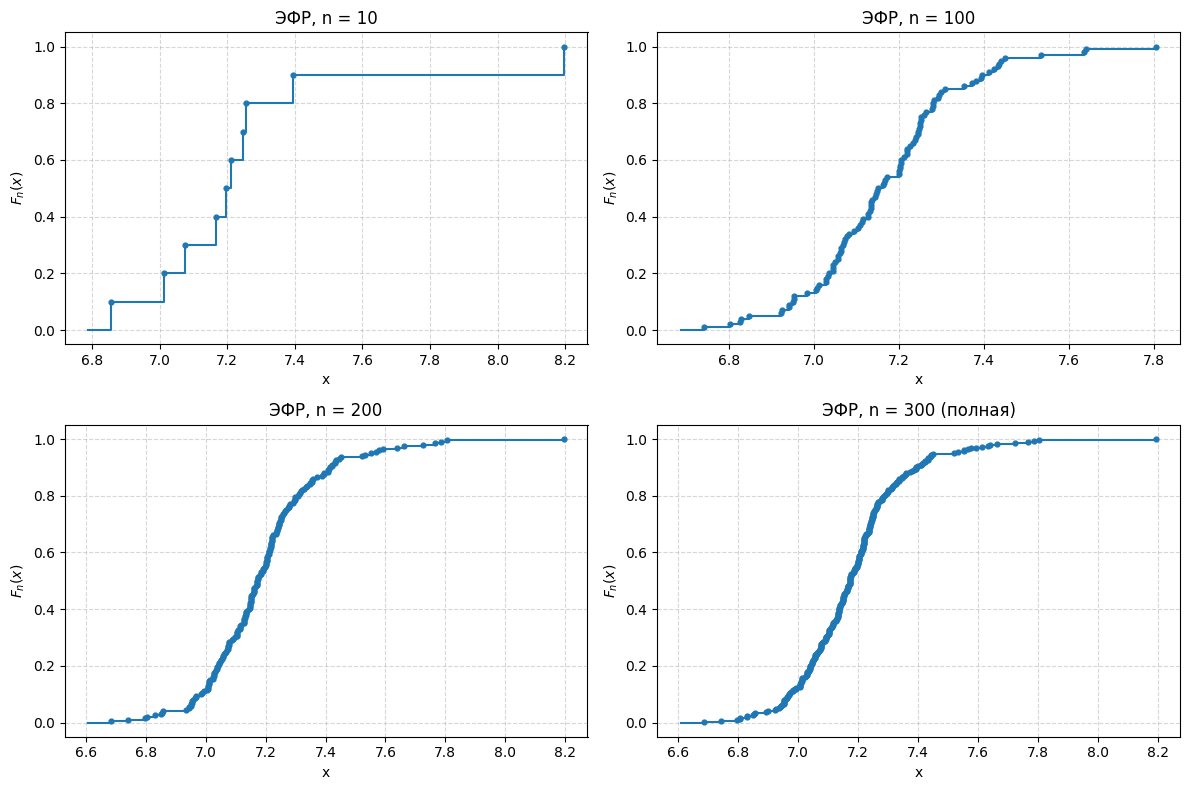

In [4]:
def ecdf(s):
    s = sorted(s); k = len(s)
    return s, [(i + 1) / k for i in range(k)]

def plot_ecdf(s, title, ax):
    xs, fs = ecdf(s)
    pad = (max(xs) - min(xs)) * 0.05 or 0.05
    ax.step([min(xs) - pad] + xs, [0.0] + fs, where='post', lw=1.5)
    ax.scatter(xs, fs, s=12, zorder=3)
    ax.set(xlabel='x', ylabel='$F_n(x)$', title=title)
    ax.grid(True, ls='--', alpha=0.5)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for a, k in zip(ax.flat[:3], (10, 100, 200)):
    sub = [sample[i] for i in RNG.choice(n, k, replace=False)]
    plot_ecdf(sub, f'ЭФР, n = {k}', a)
plot_ecdf(sample, f'ЭФР, n = {n} (полная)', ax[1, 1])
plt.tight_layout(); plt.show()

## Гистограмма

$$h_i = \dfrac{n_i}{n\,\Delta_i}, \quad k = \mathrm{round}(1 + \log_2 n)$$

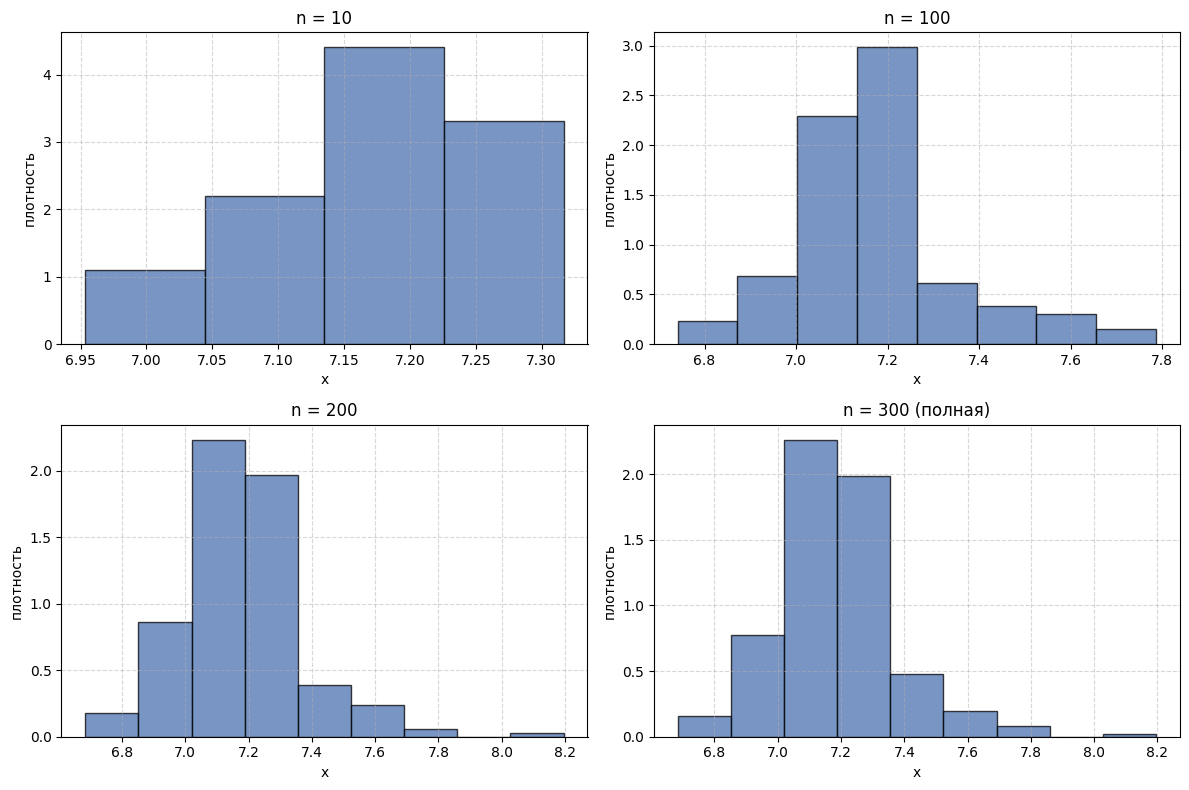

In [5]:
def histogram(s, bins=None):
    k = len(s)
    if bins is None:
        bins = max(1, round(1 + math.log2(k)))
    a, b = min(s), max(s)
    if a == b: b = a + 1.0
    edges = [a + (b - a) * i / bins for i in range(bins + 1)]
    counts = [0] * bins
    for v in s:
        idx = min(int((v - a) / (b - a) * bins), bins - 1)
        counts[idx] += 1
    dx = (b - a) / bins
    return edges, counts, [c / (k * dx) for c in counts]

def plot_hist(s, title, ax):
    edges, _, dens = histogram(s)
    w = [edges[i+1] - edges[i] for i in range(len(edges) - 1)]
    c = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges) - 1)]
    ax.bar(c, dens, width=w, edgecolor='black', color='#4C72B0', alpha=0.75)
    ax.set(xlabel='x', ylabel='плотность', title=title)
    ax.grid(True, ls='--', alpha=0.5)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for a, k in zip(ax.flat[:3], (10, 100, 200)):
    sub = [sample[i] for i in RNG.choice(n, k, replace=False)]
    plot_hist(sub, f'n = {k}', a)
plot_hist(sample, f'n = {n} (полная)', ax[1, 1])
plt.tight_layout(); plt.show()

## Теоретическая функция распределения Log-Laplace

$$f(x;\mu,b) = \dfrac{1}{2bx}\,e^{-|\ln x - \mu| / b}, \quad x > 0$$

In [6]:
def loglaplace_pdf(x, mu, b):
    if x <= 0: return 0.0
    return math.exp(-abs(math.log(x) - mu) / b) / (2 * b * x)

def loglaplace_cdf(x, mu, b):
    if x <= 0: return 0.0
    z = math.log(x) - mu
    return 0.5 * math.exp(z / b) if z <= 0 else 1.0 - 0.5 * math.exp(-z / b)

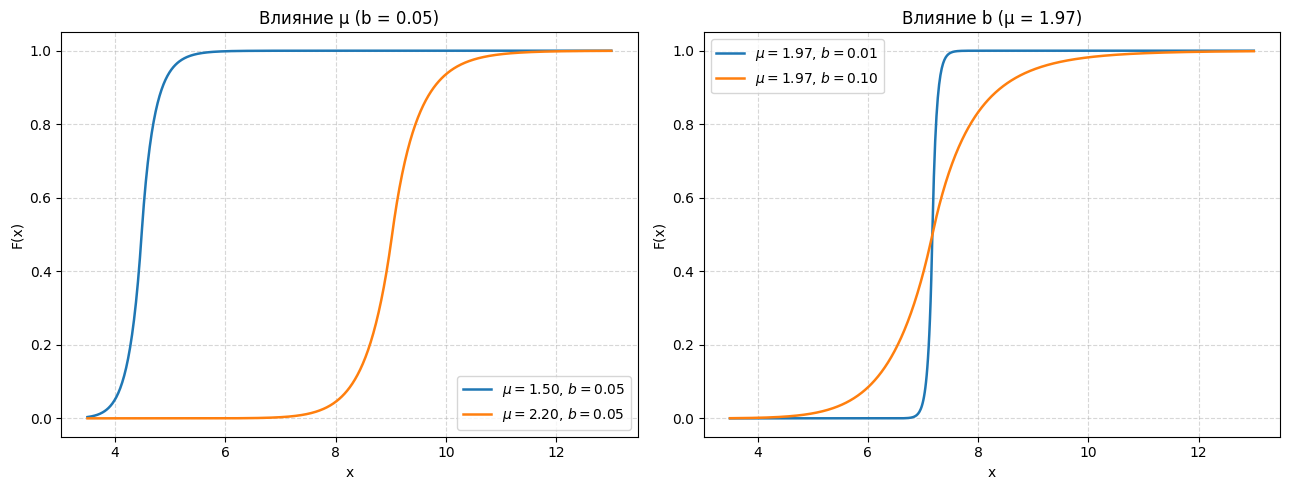

In [7]:
x_grid = np.linspace(3.5, 13.0, 800)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Влияние mu (b фиксирован)
for mu in (1.50, 2.20):
    F = [loglaplace_cdf(x, mu, 0.05) for x in x_grid]
    ax[0].plot(x_grid, F, lw=1.8, label=fr'$\mu={mu:.2f}$, $b=0.05$')
ax[0].set(xlabel='x', ylabel='F(x)', title='Влияние μ (b = 0.05)')
ax[0].grid(True, ls='--', alpha=0.5); ax[0].legend()

# Влияние b (mu фиксирован)
for b in (0.01, 0.10):
    F = [loglaplace_cdf(x, 1.97, b) for x in x_grid]
    ax[1].plot(x_grid, F, lw=1.8, label=fr'$\mu=1.97$, $b={b:.2f}$')
ax[1].set(xlabel='x', ylabel='F(x)', title='Влияние b (μ = 1.97)')
ax[1].grid(True, ls='--', alpha=0.5); ax[1].legend()

plt.tight_layout(); plt.show()

## ЭФР и теоретическая F с грубыми оценками μ̂, b̂

mu_hat = 1.971309, b_hat = 0.017877, exp(mu_hat) = 7.180071


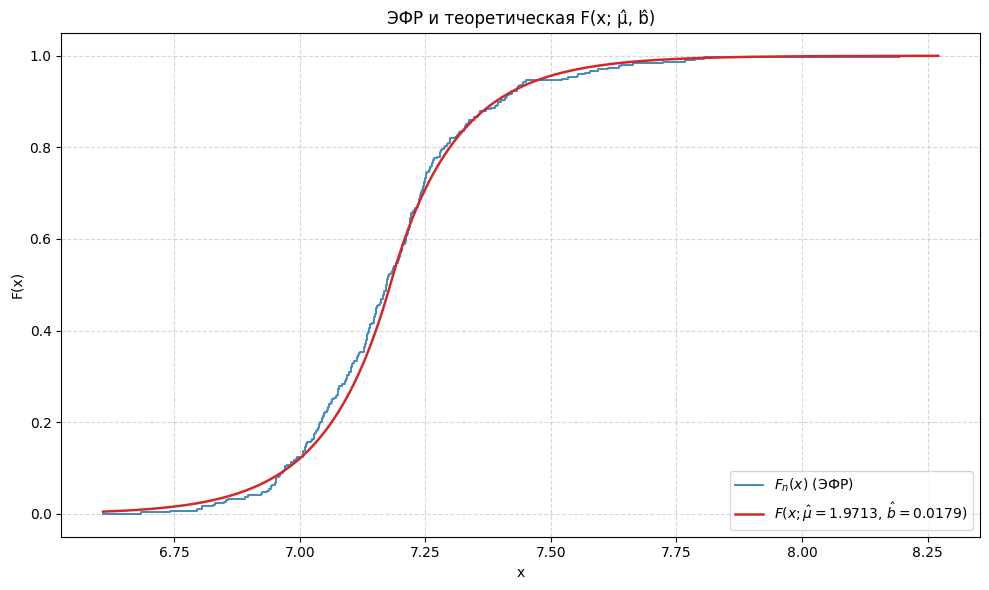

In [8]:
logs = [math.log(v) for v in sample]
mu_hat = s_mean(logs)
b_hat = math.sqrt(s_var_unbiased(logs) / 2)
print(f'mu_hat = {mu_hat:.6f}, b_hat = {b_hat:.6f}, exp(mu_hat) = {math.exp(mu_hat):.6f}')

xs, fs = ecdf(sample)
pad = (max(xs) - min(xs)) * 0.05
fig, ax = plt.subplots(figsize=(10, 6))
ax.step([min(xs) - pad] + xs, [0.0] + fs, where='post', lw=1.4,
        color='C0', alpha=0.85, label='$F_n(x)$ (ЭФР)')
grid = np.linspace(min(xs) - pad, max(xs) + pad, 600)
ax.plot(grid, [loglaplace_cdf(x, mu_hat, b_hat) for x in grid],
        lw=1.8, color='C3',
        label=fr'$F(x;\hat\mu={mu_hat:.4f},\,\hat b={b_hat:.4f})$')
ax.set(xlabel='x', ylabel='F(x)',
       title='ЭФР и теоретическая F(x; μ̂, b̂)')
ax.grid(True, ls='--', alpha=0.5); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()